In [2]:
import matplotlib.pyplot as plt
import numpy as np
import arc
import pairinteraction as pi
if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=False)
import os
from IPython.display import Latex
import scipy
import pandas as pd
from pandas import DataFrame
h = scipy.constants.h
epsilon_0 = scipy.constants.epsilon_0
a_0 = scipy.constants.physical_constants['Bohr radius']
e = scipy.constants.e


In [ ]:
import os
np.set_printoptions(legacy='1.25')
if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=False)
atom1, atom2 = 'Rb', 'Cs'
colours = ('orange', 'green', 'red', 'blue')
orbs = ('s', 'p', 'd', 'f')
change1 = -3
change2 = 0

energy_unit = 'GHz'

min_n = 40
max_n = 91
ns = np.arange(min_n,max_n)
preferQuantumDefects = True


js = [[1/2], [1/2, 3/2], [3/2, 5/2], [5/2, 7/2]]

l1, l2 = 0, 0

change2s = (-3, -2, -1, 0, 1, 2, 3)
for change2 in change2s:
    for j1 in js[l1]:
        for j2 in js[l2]:
            for l1_1 in (l1-1, l1+1):
                if l1_1 < 0:
                    continue
                for l2_1 in (l2-1, l2+1):
                    if l2_1 < 0:
                        continue
                                
                    for j1_1 in js[l1_1]:
                        if abs(j1_1 - j1) > 1:
                            continue

                        for j2_1 in js[l2_1]: 
                            if abs(j2_1 - j2) > 1:
                                continue 
                            path = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\C3s\\{atom1}{atom2}\\{orbs[l1]}{orbs[l2]}\\j1j2({j1},{j2})\\to {orbs[l1_1]}{orbs[l2_1]}\\'
                            if not os.path.exists(path):
                                os.makedirs(path)
                            if os.path.exists(path + f'{j1_1}, {j2_1} {change1} {change2} ns {min_n}{max_n}.csv') or os.path.exists(path + f'{j1_1}, {j2_1} {change1} {change2}.csv'):
                                continue
                            c3ks = []
                            n1s=[]
                            n2s=[]
                            for n1 in ns:
                                for n2 in ns:


                                
                                # Rb lowering n
                                    if atom1 == 'Rb':
                                        rb_matrix_element_j = arc.Rubidium().getReducedMatrixElementJ(n1, l1, j1, n1+change1, l1_1, j1_1)     
                                    else:
                                        rb_matrix_element_j = arc.Caesium().getReducedMatrixElementJ(n1, l1, j1, n1+change1, l1_1, j1_1)
                                    if atom2 == 'Rb':
                                        cs_matrix_element_j = arc.Rubidium().getReducedMatrixElementJ(n2, l2, j2, n2+change2, l2_1, j2_1)     
                                    else:
                                        cs_matrix_element_j = arc.Caesium().getReducedMatrixElementJ(n2, l2, j2, n2+change2, l2_1, j2_1)

                                    c3k = (a_0[0]*e) **2 / h / (4*np.pi*epsilon_0) * 1e9 * cs_matrix_element_j * rb_matrix_element_j/np.sqrt(2*j1_1+1)/np.sqrt(2*j2_1+1)

                                    n1s.append(n1)
                                    n2s.append(n2)
                                    c3ks.append(c3k)
                                    
                            c3k_data = pd.DataFrame({'n1s' : n1s, 'n2s' : n2s, 'c3k' : c3ks})
                            
                            
                            # os.path.join(path + f'j1_1, j2_1 dif  change1  change2.txt')
                            if not os.path.exists(path + 'j1_1, j2_1 change1 change2.txt'):
                                with open(path + 'j1_1, j2_1 change1 change2.txt', "w") as file:
                                    file.write("")

                            c3k_data.to_csv(path + f'{j1_1}, {j2_1} {change1} {change2} ns {min_n}{max_n}.csv', index=False)
                        print(f'change2s: {int(list(change2s).index(change2)/len(change2s)*100)}% | j1s: {int(list(js[l1]).index(j1)/len(js[l1])*100)}% | j2s: {int(list(js[l2]).index(j2)/len(js[l2])*100)}% | l1_1, l2_1: {l1_1},{l2_1}')
                                    
                                    

change2s: 0% | j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1
change2s: 0% | j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1
change2s: 14% | j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1
change2s: 14% | j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1
change2s: 28% | j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1
change2s: 28% | j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1
change2s: 42% | j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1
change2s: 42% | j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1
change2s: 57% | j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1
change2s: 57% | j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1
change2s: 71% | j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1
change2s: 71% | j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1
change2s: 85% | j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1
change2s: 85% | j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1


[ 0.67588489  0.71459568  0.75438376 ... 20.53013441 21.02526829
 21.52630129]
[]


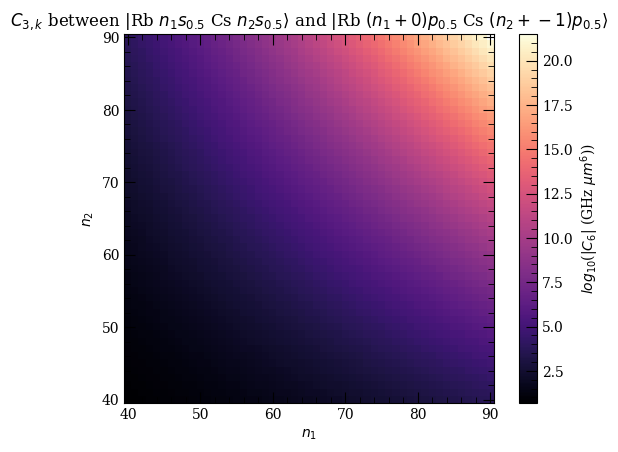

In [ ]:
from pairinteraction.visualization.colormaps import alphamagma
atom1, atom2 = 'Rb', 'Cs'

l1, l2 = 0, 0
j1, j2 = 1/2, 1/2
l1_1, l2_1 = 1, 1
j1_1, j2_1 = 1/2, 1/2

change1, change2 = 0, -2


plot_n1s=[]
plot_n2s=[]
fig, ax = plt.subplots()
ax.set_aspect('equal', adjustable='box')
c3k_path = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\data\\C3s\\{atom1}{atom2}\\{orbs[l1]}{orbs[l2]}\\j1j2({j1},{j2})\\to {orbs[l1_1]}{orbs[l2_1]}\\{j1_1}, {j2_1} {change1} {change2} ns 4091.csv'
c3k_data = pd.read_csv(c3k_path)
n1s = c3k_data['n1s'].to_numpy()
n2s = c3k_data['n2s'].to_numpy()
c3k = c3k_data['c3k'].to_numpy()
print(c3k)
red_n1s = np.arange(min(n1s), max(n1s)+1)
red_n2s = np.arange(min(n2s), max(n2s)+1)

# print(n1s)
X, Y = np.meshgrid(n1s, n2s)
Z = np.zeros((max(n1s)-min(n1s)+1,max(n2s)-min(n2s)+1))
for i, n1 in enumerate(n1s):
    Z[list(red_n2s).index(n2s[i]), list(red_n1s).index(n1)] = c3k[i]

# print(Z)
ax.set_aspect('equal', adjustable='box')

cmap = ax.imshow(Z, cmap=alphamagma.reversed(), extent=(min(n1s)-0.5, max(n1s)+0.5, min(n2s)-0.5, max(n2s)+0.5), origin='lower')

col = 0
# for l1_1 in [l1-1, l1+1]:
#     for l2_1 in [l2-1, l1+1]:
#         path = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\spreadsheets\\{atom1}{atom2}\\{orbs[l1]}{orbs[l2]} to {orbs[l1_1]}{orbs[l2_1]} j1j2({j1},{j2}).xlsx'
#         if os.path.exists(path):
#             df = pd.read_excel(path)
#             plot_n1s = df['n1_0'].to_numpy()
#             plot_n2s = df['n2_0'].to_numpy()
#             ax.plot(plot_n1s, plot_n2s, 'o', markerfacecolor='none', markersize=8, color=colours[col], markeredgewidth=2, label = f'{orbs[l1_1]} {orbs[l2_1]}')
#             col+=1
#         else:
#             continue
# print(df['n1_0'])
# np.concatenate(plot_n1s).flatten()
# np.concatenate(plot_n2s).flatten()
print(plot_n1s)

# plt.legend()

cbar = plt.colorbar(cmap, label=r'$log_{10}$(|$C_6$| (GHz $\mu m^6$))')
# cbar.set_ticks(np.arange(-2,6))
plt.xlabel(r'$n_1$')
plt.ylabel(r'$n_2$')
plt.title(rf'$C_{{3,k}}$ between |{atom1} $n_1{orbs[l1]}_{{{j1}}}$ {atom2} $n_2{orbs[l2]}_{{{j2}}}\rangle$ and |{atom1} $(n_1+{change1}){orbs[l1_1]}_{{{j1_1}}}$ {atom2} $(n_2+{change2}){orbs[l2_1]}_{{{j2_1}}}\rangle$')

c3kFigure_path = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\C3ks\\{atom1}{atom2}\\{orbs[l1]}{orbs[l2]}\\j1j2({j1},{j2})\\to {orbs[l1_1]}{orbs[l2_1]}'
if not os.path.exists(c3kFigure_path):
    os.makedirs(c3kFigure_path)
fig.savefig(c3kFigure_path + f'\\{j1_1}, {j2_1} {change1} {change2} ns {min_n}{max_n}.png')
plt.show()

[40 40 40 ... 90 90 90]
[ 0.67588489  0.71459568  0.75438376 ... 20.53013441 21.02526829
 21.52630129]


C:\Users\Tommy\AppData\Local\Temp\ipykernel_17072\4255933157.py:38: RuntimeWarning: divide by zero encountered in log10
  cmap = ax.imshow(np.log10(abs(Z)), cmap=alphamagma.reversed(), extent=(min(n1s)-0.5, max(n1s)+0.5, -8 - .5, 8 + .5), origin='lower')


-50
[]


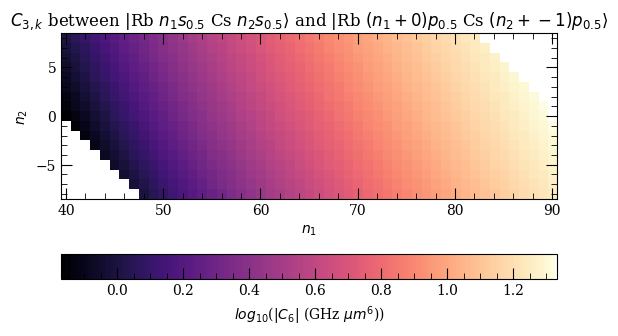

In [ ]:
from pairinteraction.visualization.colormaps import alphamagma
atom1, atom2 = 'Rb', 'Cs'

l1, l2 = 0, 0
j1, j2 = 1/2, 1/2
l1_1, l2_1 = 1, 1
j1_1, j2_1 = 1/2, 1/2

change1, change2 = 0,-1


plot_n1s=[]
plot_n2s=[]
fig, ax = plt.subplots()
ax.set_aspect('equal', adjustable='box')
c3k_path = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\data\\C3s\\{atom1}{atom2}\\{orbs[l1]}{orbs[l2]}\\j1j2({j1},{j2})\\to {orbs[l1_1]}{orbs[l2_1]}\\{j1_1}, {j2_1} {change1} {change2} ns 4091.csv'
c3k_data = pd.read_csv(c3k_path)
n1s = c3k_data['n1s'].to_numpy()
n2s = c3k_data['n2s'].to_numpy()
c3ks = c3k_data['c3k'].to_numpy()
print(n1s)
print(c3k)
red_n1s = np.arange(min(n1s), max(n1s)+1)
red_n2s = np.arange(min(n2s), max(n2s)+1)

# print(n1s)

Z = np.zeros((17, max(n1s)-min(n1s)+1))
difs = np.arange(-8, 9)
for c3k, n1, n2 in zip(c3ks, n1s, n2s):
    if abs(n2 - n1) > 8:
        continue
    Z[list(difs).index(n2 - n1), n1-min(n1s)] = c3k

# print(Z)
ax.set_aspect('equal', adjustable='box')

cmap = ax.imshow(np.log10(abs(Z)), cmap=alphamagma.reversed(), extent=(min(n1s)-0.5, max(n1s)+0.5, -8 - .5, 8 + .5), origin='lower')
print(min(n2s-n1s))
col = 0
# for l1_1 in [l1-1, l1+1]:
#     for l2_1 in [l2-1, l1+1]:
#         path = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\spreadsheets\\{atom1}{atom2}\\{orbs[l1]}{orbs[l2]} to {orbs[l1_1]}{orbs[l2_1]} j1j2({j1},{j2}).xlsx'
#         if os.path.exists(path):
#             df = pd.read_excel(path)
#             plot_n1s = df['n1_0'].to_numpy()
#             plot_n2s = df['n2_0'].to_numpy()
#             ax.plot(plot_n1s, plot_n2s, 'o', markerfacecolor='none', markersize=8, color=colours[col], markeredgewidth=2, label = f'{orbs[l1_1]} {orbs[l2_1]}')
#             col+=1
#         else:
#             continue
# print(df['n1_0'])
# np.concatenate(plot_n1s).flatten()
# np.concatenate(plot_n2s).flatten()
print(plot_n1s)

# plt.legend()

cbar = plt.colorbar(cmap, label=r'$log_{10}$(|$C_6$| (GHz $\mu m^6$))', location='bottom')
# cbar.set_ticks(np.arange(-2,6))
plt.xlabel(r'$n_1$')
plt.ylabel(r'$n_2$')
plt.title(rf'$C_{{3,k}}$ between |{atom1} $n_1{orbs[l1]}_{{{j1}}}$ {atom2} $n_2{orbs[l2]}_{{{j2}}}\rangle$ and |{atom1} $(n_1+{change1}){orbs[l1_1]}_{{{j1_1}}}$ {atom2} $(n_2+{change2}){orbs[l2_1]}_{{{j2_1}}}\rangle$')

c3kFigure_path = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\C3ks\\{atom1}{atom2}\\{orbs[l1]}{orbs[l2]}\\j1j2({j1},{j2})\\to {orbs[l1_1]}{orbs[l2_1]}'
if not os.path.exists(c3kFigure_path):
    os.makedirs(c3kFigure_path)
fig.savefig(c3kFigure_path + f'\\{j1_1}, {j2_1} {change1} {change2} ns {min_n}{max_n}.png')
plt.show()